In [1]:
#Volcado de Dato

bucket_name = 'proyectoaemet'ARadasdad
s3.upload_file("ProyectoAemet.pynb", bucket_name, "ARCHIVOS-PROYECTOARCHIVOS-PROYECTOARCHIVOS-PROYECTO/ProyectoAemet.pynb")
print("Archivo subido con éxito.")




SyntaxError: invalid syntax (2811148219.py, line 3)

In [2]:

import pandas as pd
import psycopg2
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS


conn = psycopg2.connect(
    host="database-2.cho6u08ism0b.eu-north-1.rds.amazonaws.com",
    port=5432,
    database="postgres",
    user="postgres",
    password="Aemet2026."
)

query = """
SELECT fecha, tmed, tmin, tmax, prec
FROM public.aemet_observaciones
WHERE tmed IS NOT NULL
ORDER BY fecha ASC;
"""

df = pd.read_sql(query, conn)
conn.close()


C:\Users\artir\AppData\Local\Temp\ipykernel_2020\349869719.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:

# 2. EDA BÁSICO


print("Número de registros:", len(df))
print("Rango de fechas:", df["fecha"].min(), "→", df["fecha"].max())
print("Temperatura media (media global):", round(df["tmed"].mean(), 2))

Número de registros: 157
Rango de fechas: 2025-11-01 → 2026-04-06
Temperatura media (media global): 8.76


In [4]:
df

,fecha,tmed,tmin,tmax,prec
0,2025-11-01,15.4,11.9,18.8,0.0
1,2025-11-02,13.2,7.6,18.8,0.0
2,2025-11-03,11.9,3.8,20.0,0.0
3,2025-11-04,11.9,3.7,20.1,0.0
4,2025-11-05,13.5,9.7,17.3,0.9
...,...,...,...,...,...
152,2026-04-02,12.6,6.6,18.5,0.0
153,2026-04-03,12.2,2.0,22.3,0.0
154,2026-04-04,14.8,5.5,24.0,0.0
155,2026-04-05,16.6,6.6,26.5,0.0


In [5]:
df.head

<bound method NDFrame.head of           fecha  tmed  tmin  tmax  prec
0    2025-11-01  15.4  11.9  18.8   0.0
1    2025-11-02  13.2   7.6  18.8   0.0
2    2025-11-03  11.9   3.8  20.0   0.0
3    2025-11-04  11.9   3.7  20.1   0.0
4    2025-11-05  13.5   9.7  17.3   0.9
..          ...   ...   ...   ...   ...
152  2026-04-02  12.6   6.6  18.5   0.0
153  2026-04-03  12.2   2.0  22.3   0.0
154  2026-04-04  14.8   5.5  24.0   0.0
155  2026-04-05  16.6   6.6  26.5   0.0
156  2026-04-06  16.4   7.1  25.7   0.0

[157 rows x 5 columns]>

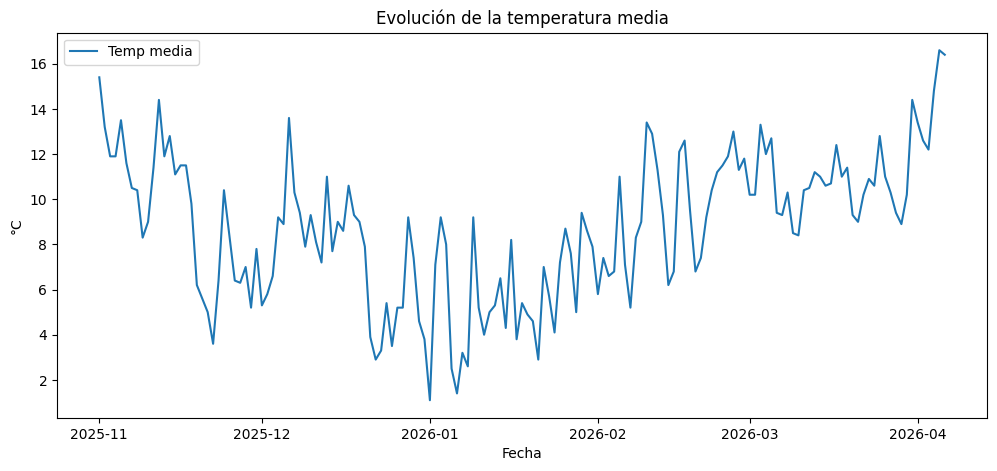

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df['fecha'], df['tmed'], label='Temp media')
plt.title('Evolución de la temperatura media')
plt.xlabel('Fecha')
plt.ylabel('°C')
plt.legend()
plt.show()

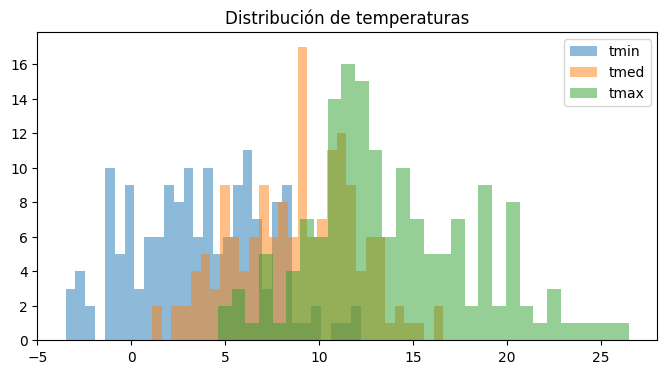

In [7]:
plt.figure(figsize=(8,4))
plt.hist(df['tmin'], bins=30, alpha=0.5, label='tmin')
plt.hist(df['tmed'], bins=30, alpha=0.5, label='tmed')
plt.hist(df['tmax'], bins=30, alpha=0.5, label='tmax')
plt.legend()
plt.title('Distribución de temperaturas')
plt.show()

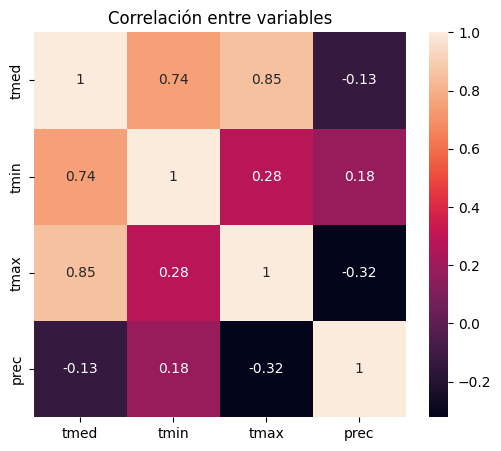

In [8]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[['tmed','tmin','tmax','prec']].corr(), annot=True)
plt.title('Correlación entre variables')
plt.show()

In [9]:

# 3. PREPROCESAMIENTO


df["fecha"] = pd.to_datetime(df["fecha"])
df["prec"] = df["prec"].fillna(0)

df = df.groupby("fecha").mean(numeric_only=True).reset_index()


In [10]:

# 4. FEATURE ENGINEERING


df["month"] = df["fecha"].dt.month
df["dayofweek"] = df["fecha"].dt.dayofweek
df["dayofyear"] = df["fecha"].dt.dayofyear

for lag in [1, 2, 3, 7]:
    df[f"tmed_lag{lag}"] = df["tmed"].shift(lag)

df = df.dropna().reset_index(drop=True)

In [11]:

# 5. VARIABLES


features = [
    "tmed_lag1", "tmed_lag2", "tmed_lag3", "tmed_lag7",
    "tmin", "tmax", "prec",
    "month", "dayofweek", "dayofyear"
]

X = df[features]
y = df["tmed"]

In [12]:

# 6. SPLIT TEMPORAL


split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [13]:

# 7. MODELO
# Se ha utilizado un RandomForestRegressor con 200 árboles y profundidad máxima 10 para evitar sobreajuste y capturar relaciones no lineales en los datos.

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:

# 8. EVALUACIÓN

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\nEvaluación del modelo:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


Evaluación del modelo:
MAE: 0.86
RMSE: 1.31


In [15]:

# 9. GUARDADO


joblib.dump(model, "model.pkl")

print("\nModelo guardado como model.pkl")


Modelo guardado como model.pkl


In [16]:
def predict_next_day(df, model):
    last = df.iloc[-1]

    X = [[
        last['tmed'],
        last['tmed_lag1'],
        last['tmed_lag2'],
        last['tmed_lag7'],
        last['tmin'],
        last['tmax'],
        last['prec'],
        last['month'],
        last['dayofweek'],
        last['dayofyear'] + 1
    ]]

    return model.predict(X)[0]

print("Predicción mañana:", predict_next_day(df, model))

Predicción mañana: 12.561250000000006


C:\Users\artir\miniconda3\envs\mi_entorno\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [17]:
model = joblib.load("model.pkl")

def predict_next_day(df):
    last = df.iloc[-1]

    X = [[
        last['tmed'],
        last['tmed_lag1'],
        last['tmed_lag2'],
        last['tmed_lag7'],
        last['tmin'],
        last['tmax'],
        last['prec'],
        last['month'],
        last['dayofweek'],
        last['dayofyear'] + 1
    ]]

    return model.predict(X)[0]